# 04 — Video Tracking Pipeline

Goal: Use SAM-2 VideoPredictor to propagate object segmentation masks
across YouTube-VIS video sequences. YOLO-World detections on frame 0
serve as box prompts. SAM-2 then tracks every detected object through
all remaining frames without re-running detection.

Pipeline per video:
  Frame 0 → YOLO-World detects objects → box prompts → SAM-2
  Frames 1..N → SAM-2 propagates masks automatically

Sections:
  A) Load video index, select sample videos
  B) Copy frames to local SSD
  C) Load models
  D) Run tracking pipeline
  E) Compute tracking metrics
  F) Visualize and save to Drive

Inputs:
  - processed/youtube_vis/video_index.json
  - processed/youtube_vis/category_map.json
  - raw/Youtube VIS/train/JPEGImages/<vid_folder>/
  - checkpoints/yoloworld/yolov8l-world-finetuned.pt
  - checkpoints/sam2/sam2.1_hiera_large.pt

Outputs:
  - outputs/metrics/tracking_results.json
  - outputs/metrics/tracking_per_video.csv
  - outputs/visualizations/tracking/<vid_folder>/  (annotated frames)
  - outputs/visualizations/tracking_grids/         (summary grids)

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 0a: Install packages
# ─────────────────────────────────────────────────────────────
import subprocess, sys

def install(pkg, label=None):
    label = label or pkg
    print(f"  Installing {label}...", end=" ", flush=True)
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                       capture_output=True, text=True)
    print("✅" if r.returncode == 0 else f"❌\n{r.stderr[-300:]}")

print("Installing packages...")
install("ultralytics==8.3.145",   "ultralytics (pinned)")
install("supervision",            "supervision")
install("opencv-python-headless", "opencv-headless")
install("pycocotools",            "pycocotools")
install("hydra-core",             "hydra-core")
install("iopath",                 "iopath")
install("submitit",               "submitit")
install("einops",                 "einops")
install("git+https://github.com/ultralytics/CLIP.git", "CLIP")

print("\n✅ All packages installed. Run Cell 0b next.")

Installing packages...
  Installing ultralytics (pinned)... ✅
  Installing supervision... ✅
  Installing opencv-headless... ✅
  Installing pycocotools... ✅
  Installing hydra-core... ✅
  Installing iopath... ✅
  Installing submitit... ✅
  Installing einops... ✅
  Installing CLIP... ✅

✅ All packages installed. Run Cell 0b next.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 0b: Clone repos, sys.path, verify imports
# Run AFTER Cell 0a completes fully.
# ─────────────────────────────────────────────────────────────
import subprocess, sys, os, importlib

importlib.invalidate_caches()
for mod in list(sys.modules.keys()):
    if mod in ("sam2","ultralytics","hydra") or \
       mod.startswith(("sam2.","ultralytics.","hydra.")):
        del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive')

import json
CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

YOLOWORLD_REPO = cfg["yoloworld_repo"]
SAM2_REPO      = cfg["sam2_repo"]

def clone_if_missing(path, url, name):
    if not os.path.exists(path):
        print(f"  Cloning {name}...", end=" ", flush=True)
        r = subprocess.run(f"git clone -q {url} {path}",
                           shell=True, capture_output=True, text=True)
        print("✅" if r.returncode == 0 else f"❌ {r.stderr[-100:]}")
    else:
        print(f"  {name} already present ✅")

clone_if_missing(YOLOWORLD_REPO,
                 "https://github.com/AILab-CVC/YOLO-World.git", "YOLO-World")
clone_if_missing(SAM2_REPO,
                 "https://github.com/facebookresearch/sam2.git", "SAM-2")

if SAM2_REPO not in sys.path:
    sys.path.insert(0, SAM2_REPO)

print("\nVerifying imports...")
import torch
print(f"  torch      : {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    raise RuntimeError("No GPU. Go to Runtime → Change runtime type → T4 GPU.")

try:
    import ultralytics; from ultralytics import YOLO
    print(f"  ultralytics: {ultralytics.__version__} ✅")
except Exception as e:
    print(f"  ultralytics: ❌ {e}")
try:
    import hydra
    print(f"  hydra-core : {hydra.__version__} ✅")
except Exception as e:
    print(f"  hydra-core : ❌ {e}  ← re-run Cell 0a")
try:
    from sam2.build_sam import build_sam2_video_predictor
    from sam2.sam2_video_predictor import SAM2VideoPredictor
    print(f"  SAM-2      : ✅")
except Exception as e:
    print(f"  SAM-2      : ❌ {e}")
try:
    import cv2; print(f"  opencv     : {cv2.__version__} ✅")
except Exception as e:
    print(f"  opencv     : ❌ {e}")

print("\n✅ Cell 0b complete.")

Mounted at /content/drive
  Cloning YOLO-World... ✅
  Cloning SAM-2... ✅

Verifying imports...
  torch      : 2.10.0+cu128 | CUDA: True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  ultralytics: 8.3.145 ✅
  hydra-core : 1.3.2 ✅
  SAM-2      : ✅
  opencv     : 4.13.0 ✅

✅ Cell 0b complete.


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Imports, config, all path variables, staging dirs
# ─────────────────────────────────────────────────────────────
import json, os, sys, shutil, subprocess, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

CONFIG_PATH = "/content/drive/MyDrive/DLCV_OV_Analytics/configs/config.json"
with open(CONFIG_PATH) as f:
    cfg = json.load(f)

# ── Paths ─────────────────────────────────────────────────────
RAW_YTVIS       = cfg["raw_ytvis"]
PROC_YTVIS      = cfg["proc_ytvis"]
OUTPUT_DIR      = cfg["output_dir"]
VIZ_DIR         = cfg["viz_dir"]
METRICS_DIR     = cfg["metrics_dir"]
SAM2_REPO       = cfg["sam2_repo"]
SAM2_CKPT_PATH  = cfg["sam2_ckpt_path"]
DEVICE          = cfg.get("device", "cuda")

# Fine-tuned YOLO-World checkpoint (written by NB03)
YW_FT_CKPT_PATH = cfg.get(
    "yw_finetuned_ckpt_path",
    os.path.join(cfg["ckpt_yoloworld"], "yolov8l-world-finetuned.pt")
)

VIDEO_INDEX_PATH = os.path.join(PROC_YTVIS, "video_index.json")
CAT_MAP_PATH     = os.path.join(PROC_YTVIS, "category_map.json")
RAW_TRAIN_FRAMES = os.path.join(RAW_YTVIS, "train", "JPEGImages")
RAW_VAL_FRAMES   = os.path.join(RAW_YTVIS, "valid", "JPEGImages")

# ── YOLO-World classes (VisDrone — fine-tuned model)  ─────────
YOLO_CLASSES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor", "others"
]

# ── Local staging ─────────────────────────────────────────────
STAGE               = "/content/staging/tracking"
STAGE_METRICS       = f"{STAGE}/metrics"
STAGE_VIZ_FRAMES    = f"{STAGE}/visualizations/tracking"
STAGE_VIZ_GRIDS     = f"{STAGE}/visualizations/tracking_grids"
LOCAL_FRAMES_DIR    = "/content/ytvis_frames"   # video frames on local SSD

for d in [STAGE_METRICS, STAGE_VIZ_FRAMES, STAGE_VIZ_GRIDS, LOCAL_FRAMES_DIR]:
    os.makedirs(d, exist_ok=True)

def cp_sync(src, dst_dir):
    r = subprocess.run(f"cp '{src}' '{dst_dir}/' && sync",
                       shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        raise IOError(f"cp failed: {r.stderr}")
    return os.path.join(dst_dir, os.path.basename(src))

# ── Verify inputs ─────────────────────────────────────────────
print("Verifying inputs...")
all_ok = True
for name, path in [
    ("video_index.json",        VIDEO_INDEX_PATH),
    ("category_map.json",       CAT_MAP_PATH),
    ("raw train frames",        RAW_TRAIN_FRAMES),
    ("fine-tuned YOLO-World",   YW_FT_CKPT_PATH),
    ("SAM-2 checkpoint",        SAM2_CKPT_PATH),
]:
    exists = os.path.exists(path)
    if os.path.isdir(path):
        n = len(os.listdir(path))
        print(f"  {'✅' if exists else '❌ MISSING'}  {name}: {n:,} entries")
    else:
        print(f"  {'✅' if exists else '❌ MISSING'}  {name}")
    if not exists:
        all_ok = False

if all_ok:
    print(f"\n✅ Cell 1 complete. Device: {DEVICE}")
else:
    print("\n❌ Fix missing inputs before continuing.")

Verifying inputs...
  ✅  video_index.json
  ✅  category_map.json
  ✅  raw train frames: 2,985 entries
  ✅  fine-tuned YOLO-World
  ✅  SAM-2 checkpoint

✅ Cell 1 complete. Device: cuda


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 2: Load video_index + category_map, select sample videos
# ─────────────────────────────────────────────────────────────

# ── Load video index ──────────────────────────────────────────
with open(VIDEO_INDEX_PATH) as f:
    video_index_raw = json.load(f)

# Keys are strings in JSON — convert back to int
video_index = {int(k): v for k, v in video_index_raw.items()}

# ── Load category map ─────────────────────────────────────────
with open(CAT_MAP_PATH) as f:
    cat_map = json.load(f)

# ytvis_cat_to_yolo: {ytvis_cat_id: yolo_cls_id}
# yolo_to_cat_name:  {yolo_cls_id:  category_name}
ytvis_cat_to_yolo = {int(k): v for k, v in cat_map["ytvis_cat_to_yolo"].items()}
yolo_to_cat_name  = {int(k): v for k, v in cat_map["yolo_to_cat_name"].items()}

print(f"Video index loaded: {len(video_index):,} videos")
print(f"Categories        : {len(ytvis_cat_to_yolo)} classes")
print(f"Sample categories : {list(yolo_to_cat_name.values())[:8]}...")

# ── Select N sample videos for tracking ──────────────────────
# Criteria:
# 1. Video frames exist on disk (vid_entry['exists'] == True)
# 2. Video length >= 10 frames (enough temporal context)
# 3. Video length <= 36 frames (keeps GPU memory reasonable)
# We track 10 videos for the demo — enough for meaningful metrics

N_VIDEOS    = 10
MIN_FRAMES  = 10
MAX_FRAMES  = 36

train_videos = [
    (vid_id, info) for vid_id, info in video_index.items()
    if info["split"] == "train"
    and info["exists"]
    and MIN_FRAMES <= info["length"] <= MAX_FRAMES
]

# Sort by length descending for variety, then take N
train_videos.sort(key=lambda x: -x[1]["length"])
# Take every Nth to get a spread of different video folders
step = max(1, len(train_videos) // N_VIDEOS)
selected = [train_videos[i] for i in range(0, len(train_videos), step)][:N_VIDEOS]

print(f"\nTotal eligible train videos : {len(train_videos):,}")
print(f"Selected for tracking       : {len(selected)}")
print(f"\nSelected videos:")
for vid_id, info in selected:
    print(f"  vid_id={vid_id:4d}  folder={info['vid_folder']}  "
          f"frames={info['length']:3d}  "
          f"path_exists={info['exists']}")

Video index loaded: 2,985 videos
Categories        : 40 classes
Sample categories : ['airplane', 'bear', 'bird', 'boat', 'car', 'cat', 'cow', 'deer']...

Total eligible train videos : 2,164
Selected for tracking       : 10

Selected videos:
  vid_id= 493  folder=3d5aeac5ba  frames= 36  path_exists=True
  vid_id=1031  folder=7a802264c4  frames= 36  path_exists=True
  vid_id=1585  folder=ba3fcd417d  frames= 36  path_exists=True
  vid_id=2209  folder=05789662af  frames= 36  path_exists=True
  vid_id= 799  folder=610e38b751  frames= 30  path_exists=True
  vid_id=2366  folder=36198a1c34  frames= 30  path_exists=True
  vid_id=2280  folder=1b2f691839  frames= 29  path_exists=True
  vid_id= 893  folder=6a80d2e2e5  frames= 20  path_exists=True
  vid_id=2066  folder=f23e95dbe5  frames= 20  path_exists=True
  vid_id=1632  folder=bf961167a6  frames= 19  path_exists=True


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 3: Copy selected video frames to local SSD
#
# SAM2 init_state() reads every frame into GPU memory.
# Reading from Drive (FUSE) is ~10x slower than local SSD.
# Total data: 10 videos * ~36 frames * ~100KB = ~36MB — tiny.
# ─────────────────────────────────────────────────────────────

print("Copying video frames to local SSD...")
local_video_paths = {}   # vid_id → local frame directory

for vid_id, info in selected:
    drive_frame_dir = info["vid_img_path"]   # on Drive
    local_frame_dir = os.path.join(LOCAL_FRAMES_DIR, info["vid_folder"])

    os.makedirs(local_frame_dir, exist_ok=True)

    # Check if already copied
    existing = len(os.listdir(local_frame_dir))
    n_frames = info["length"]

    if existing >= n_frames:
        print(f"  ✅ {info['vid_folder']}: already on SSD ({existing} frames)")
        local_video_paths[vid_id] = local_frame_dir
        continue

    if not os.path.isdir(drive_frame_dir):
        print(f"  ❌ {info['vid_folder']}: source not found at {drive_frame_dir}")
        continue

    # Copy frames
    fnames = info["file_names"]
    copied = 0
    for fname in fnames:
        src = os.path.join(os.path.dirname(drive_frame_dir),
                           info["vid_folder"], os.path.basename(fname))
        # YouTube-VIS file_names are like '001/00001.jpg'
        # Actual path: RAW_YTVIS/train/JPEGImages/001/00001.jpg
        src_alt = os.path.join(RAW_TRAIN_FRAMES, info["vid_folder"],
                               os.path.basename(fname))
        src_path = src_alt if os.path.exists(src_alt) else src
        dst = os.path.join(local_frame_dir, os.path.basename(fname))
        if os.path.exists(src_path) and not os.path.exists(dst):
            shutil.copy2(src_path, dst)
            copied += 1

    local_video_paths[vid_id] = local_frame_dir
    print(f"  ✅ {info['vid_folder']}: {copied} frames copied")

print(f"\n✅ Cell 3 complete. {len(local_video_paths)} videos ready on local SSD.")

# Verify SAM2 can read these frames (integer-named .jpg files)
print("\nVerifying frame naming compatibility with SAM-2...")
for vid_id, local_dir in list(local_video_paths.items())[:2]:
    frames = sorted(os.listdir(local_dir))
    print(f"  {os.path.basename(local_dir)}: "
          f"{len(frames)} frames, first='{frames[0]}', last='{frames[-1]}'")
    # SAM2 requires int(stem) to work
    try:
        _ = [int(Path(f).stem) for f in frames if f.endswith(".jpg")]
        print(f"    ✅ Frame names are integer-parseable")
    except ValueError as e:
        print(f"    ⚠️  Non-integer frame name: {e}")
        print(f"    Renaming frames to 00000.jpg format...")
        for i, fname in enumerate(sorted(frames)):
            old = os.path.join(local_dir, fname)
            new = os.path.join(local_dir, f"{i:05d}.jpg")
            if old != new:
                os.rename(old, new)
        print(f"    ✅ Renamed {len(frames)} frames")

Copying video frames to local SSD...
  ✅ 3d5aeac5ba: 36 frames copied
  ✅ 7a802264c4: 36 frames copied
  ✅ ba3fcd417d: 36 frames copied
  ✅ 05789662af: 36 frames copied
  ✅ 610e38b751: 30 frames copied
  ✅ 36198a1c34: 30 frames copied
  ✅ 1b2f691839: 29 frames copied
  ✅ 6a80d2e2e5: 20 frames copied
  ✅ f23e95dbe5: 20 frames copied
  ✅ bf961167a6: 19 frames copied

✅ Cell 3 complete. 10 videos ready on local SSD.

Verifying frame naming compatibility with SAM-2...
  3d5aeac5ba: 36 frames, first='00000.jpg', last='00175.jpg'
    ✅ Frame names are integer-parseable
  7a802264c4: 36 frames, first='00000.jpg', last='00175.jpg'
    ✅ Frame names are integer-parseable


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 4: Load fine-tuned YOLO-World + SAM-2 VideoPredictor
# ─────────────────────────────────────────────────────────────
import torch
from ultralytics import YOLO
from sam2.build_sam import build_sam2_video_predictor

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected. Switch to GPU runtime.")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM available: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Load fine-tuned YOLO-World ────────────────────────────────
print("\nLoading fine-tuned YOLO-World...")
if not os.path.exists(YW_FT_CKPT_PATH):
    raise FileNotFoundError(
        f"Fine-tuned checkpoint not found: {YW_FT_CKPT_PATH}\n"
        "Run Notebook 03 first."
    )
yw_model = YOLO(YW_FT_CKPT_PATH)
# Note: set_classes() NOT called — fine-tuned model has VisDrone classes built in

# Quick warmup
dummy = np.zeros((64, 64, 3), dtype=np.uint8)
_ = yw_model.predict(dummy, verbose=False)
del dummy
print(f"✅ YOLO-World loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ── Load SAM-2 VideoPredictor ─────────────────────────────────
# config_file MUST be relative to sam2 package — not an absolute path
# build_sam2_video_predictor uses Hydra compose internally
print("\nLoading SAM-2 VideoPredictor...")
sam2_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
video_predictor = build_sam2_video_predictor(
    sam2_cfg,
    SAM2_CKPT_PATH,
    device=DEVICE
)
print(f"✅ SAM-2 VideoPredictor loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

GPU: NVIDIA A100-SXM4-40GB
VRAM available: 42.4 GB

Loading fine-tuned YOLO-World...
✅ YOLO-World loaded. VRAM: 0.23 GB

Loading SAM-2 VideoPredictor...
✅ SAM-2 VideoPredictor loaded. VRAM: 1.28 GB


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 5: Run YOLO-World → SAM-2 tracking on selected videos
#
# Per video:
# 1. Read first frame → YOLO-World detects objects
# 2. For each detection: add_new_points_or_box() on frame 0
# 3. propagate_in_video() → SAM-2 tracks across all frames
# 4. Save per-frame masks + annotated images locally
# ─────────────────────────────────────────────────────────────

COLOR_MAP = {
    0:(255,80,80),   1:(255,160,80),  2:(80,180,80),   3:(80,120,255),
    4:(180,80,255),  5:(255,220,60),  6:(80,220,220),   7:(200,120,80),
    8:(255,100,180), 9:(100,200,100), 10:(180,180,180),
}

def draw_mask_on_frame(img_rgb, mask, color_rgb, alpha=0.5):
    """Blend a binary mask onto an RGB image."""
    overlay = img_rgb.copy().astype(float)
    color   = np.array(color_rgb, dtype=float)
    overlay[mask] = overlay[mask] * (1 - alpha) + color * alpha
    return overlay.astype(np.uint8)

def draw_box_on_frame(img_rgb, box, color_rgb, label=""):
    """Draw a bounding box + label onto an RGB image (in-place)."""
    x1, y1, x2, y2 = [int(v) for v in box]
    cv2.rectangle(img_rgb, (x1,y1), (x2,y2),
                  tuple(int(c) for c in color_rgb), 2)
    if label:
        cv2.putText(img_rgb, label, (x1, max(0, y1-4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4,
                    tuple(int(c) for c in color_rgb), 1)
    return img_rgb


# ── Main tracking loop ────────────────────────────────────────
all_tracking_results = []   # one entry per video
frame_annotations    = {}   # vid_id → {frame_idx: annotated_img}

print(f"Running tracking on {len(local_video_paths)} videos...\n")

for vid_id, local_frame_dir in local_video_paths.items():
    info      = video_index[vid_id]
    vid_folder = info["vid_folder"]

    print(f"── Video {vid_id} ({vid_folder})  [{info['length']} frames] ──")

    # Get sorted frame paths
    frame_files = sorted(
        [f for f in os.listdir(local_frame_dir) if f.endswith(".jpg")],
        key=lambda p: int(Path(p).stem)
    )
    if not frame_files:
        print(f"  ❌ No frames found — skipping")
        continue

    first_frame_path = os.path.join(local_frame_dir, frame_files[0])
    first_frame_bgr  = cv2.imread(first_frame_path)
    if first_frame_bgr is None:
        print(f"  ❌ Cannot read first frame — skipping")
        continue

    first_frame_rgb = cv2.cvtColor(first_frame_bgr, cv2.COLOR_BGR2RGB)
    img_h, img_w    = first_frame_rgb.shape[:2]

    # ── Step 1: Detect on frame 0 ────────────────────────────
    results = yw_model.predict(first_frame_rgb, verbose=False, conf=0.25)
    detections = []
    if results and results[0].boxes is not None:
        for box in results[0].boxes:
            detections.append({
                "cls_id": int(box.cls.item()),
                "class" : YOLO_CLASSES[int(box.cls.item())],
                "conf"  : float(box.conf.item()),
                "box"   : box.xyxy[0].tolist(),   # [x1,y1,x2,y2] pixels
            })

    print(f"  Frame 0 detections: {len(detections)}")
    if not detections:
        print(f"  ⚠️  No detections on frame 0 — skipping this video")
        all_tracking_results.append({
            "vid_id": vid_id, "vid_folder": vid_folder,
            "n_frames": info["length"], "n_detections_frame0": 0,
            "n_objects_tracked": 0, "mean_mask_area": 0,
            "frames_with_masks": 0, "tracking_coverage": 0.0,
        })
        continue

    # ── Step 2: Initialize SAM-2 inference state ──────────────
    # video_path = JPEG folder; SAM-2 reads all frames automatically
    with torch.inference_mode():
        inference_state = video_predictor.init_state(
            video_path          = local_frame_dir,
            offload_video_to_cpu= False,   # keep on GPU for speed
            offload_state_to_cpu= False,
        )
        video_predictor.reset_state(inference_state)

        # ── Step 3: Add box prompt for each detection ─────────
        # obj_id = detection index (must be unique integer per object)
        for obj_id, det in enumerate(detections):
            box_np = np.array(det["box"], dtype=np.float32)  # shape (4,)
            _, out_obj_ids, out_mask_logits = \
                video_predictor.add_new_points_or_box(
                    inference_state = inference_state,
                    frame_idx       = 0,   # prompt on first frame
                    obj_id          = obj_id,
                    box             = box_np,
                )

        # ── Step 4: Propagate across all frames ───────────────
        # propagate_in_video yields (frame_idx, obj_ids, mask_logits)
        # mask_logits shape: (n_objects, 1, H, W)
        # mask = (logits > 0.0).squeeze(1) → (n_objects, H, W)

        video_masks     = {}   # frame_idx → {obj_id: binary_mask}
        total_mask_area = 0
        frames_with_masks = 0

        for frame_idx, obj_ids, mask_logits in \
                video_predictor.propagate_in_video(inference_state):

            # Squeeze extra dimension: (N,1,H,W) → (N,H,W)
            masks = (mask_logits > 0.0).squeeze(1).cpu().numpy()  # bool

            frame_masks = {}
            for i, o_id in enumerate(obj_ids):
                if i < len(masks):
                    frame_masks[int(o_id)] = masks[i]
                    total_mask_area += int(masks[i].sum())

            video_masks[frame_idx] = frame_masks
            if frame_masks:
                frames_with_masks += 1

        # ── Step 5: Render annotated frames ───────────────────
        annotated_frames = {}
        for fi, frame_file in enumerate(frame_files):
            frame_bgr = cv2.imread(os.path.join(local_frame_dir, frame_file))
            if frame_bgr is None:
                continue
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            canvas    = frame_rgb.copy()

            if fi in video_masks:
                for obj_id, mask in video_masks[fi].items():
                    if obj_id < len(detections):
                        cls_id = detections[obj_id]["cls_id"]
                        color  = COLOR_MAP.get(cls_id, (200,200,200))
                        canvas = draw_mask_on_frame(canvas, mask, color, alpha=0.45)

                        # Draw box on frame 0 only (prompt frame)
                        if fi == 0:
                            draw_box_on_frame(
                                canvas,
                                detections[obj_id]["box"],
                                color,
                                f"{detections[obj_id]['class']} {detections[obj_id]['conf']:.2f}"
                            )

            # Frame counter overlay
            cv2.putText(canvas, f"Frame {fi+1}/{len(frame_files)}",
                        (8, 20), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (255,255,255), 1)
            annotated_frames[fi] = canvas

        frame_annotations[vid_id] = annotated_frames

    # ── Per-video stats ───────────────────────────────────────
    n_frames   = len(frame_files)
    n_objects  = len(detections)
    coverage   = frames_with_masks / n_frames if n_frames > 0 else 0
    mean_area  = (total_mask_area / max(frames_with_masks * n_objects, 1))

    all_tracking_results.append({
        "vid_id"             : vid_id,
        "vid_folder"         : vid_folder,
        "n_frames"           : n_frames,
        "n_detections_frame0": len(detections),
        "n_objects_tracked"  : n_objects,
        "mean_mask_area_px"  : round(mean_area, 1),
        "frames_with_masks"  : frames_with_masks,
        "tracking_coverage"  : round(coverage, 4),
    })

    print(f"  Objects tracked    : {n_objects}")
    print(f"  Frames propagated  : {frames_with_masks}/{n_frames} "
          f"(coverage={coverage:.1%})")
    print(f"  Mean mask area     : {mean_area:.0f} px")

    # Reset state to free GPU memory between videos
    video_predictor.reset_state(inference_state)
    torch.cuda.empty_cache()
    print()

print(f"✅ Tracking complete. {len(all_tracking_results)} videos processed.")

Running tracking on 10 videos...

── Video 493 (3d5aeac5ba)  [36 frames] ──
  Frame 0 detections: 0
  ⚠️  No detections on frame 0 — skipping this video
── Video 1031 (7a802264c4)  [36 frames] ──
  Frame 0 detections: 0
  ⚠️  No detections on frame 0 — skipping this video
── Video 1585 (ba3fcd417d)  [36 frames] ──
  Frame 0 detections: 2


frame loading (JPEG): 100%|██████████| 36/36 [00:01<00:00, 26.98it/s]
/content/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 36/36 [00:07<00:00,  4.63it/s]


  Objects tracked    : 2
  Frames propagated  : 36/36 (coverage=100.0%)
  Mean mask area     : 17429 px

── Video 2209 (05789662af)  [36 frames] ──
  Frame 0 detections: 1


propagate in video: 100%|██████████| 36/36 [00:06<00:00,  5.83it/s]


  Objects tracked    : 1
  Frames propagated  : 36/36 (coverage=100.0%)
  Mean mask area     : 2168 px

── Video 799 (610e38b751)  [30 frames] ──
  Frame 0 detections: 0
  ⚠️  No detections on frame 0 — skipping this video
── Video 2366 (36198a1c34)  [30 frames] ──
  Frame 0 detections: 2


...

  Objects tracked    : 1
  Frames propagated  : 29/29 (coverage=100.0%)
  Mean mask area     : 6566 px

── Video 893 (6a80d2e2e5)  [20 frames] ──
  Frame 0 detections: 11


propagate in video: 100%|██████████| 20/20 [00:11<00:00,  1.75it/s]


  Objects tracked    : 11
  Frames propagated  : 20/20 (coverage=100.0%)
  Mean mask area     : 7439 px

── Video 2066 (f23e95dbe5)  [20 frames] ──
  Frame 0 detections: 1


propagate in video: 100%|██████████| 20/20 [00:03<00:00,  6.03it/s]


  Objects tracked    : 1
  Frames propagated  : 20/20 (coverage=100.0%)
  Mean mask area     : 227535 px

── Video 1632 (bf961167a6)  [19 frames] ──
  Frame 0 detections: 0
  ⚠️  No detections on frame 0 — skipping this video
✅ Tracking complete. 10 videos processed.


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 6: Compute tracking metrics
#
# Since YouTube-VIS val GT masks are withheld, we use:
# 1. Tracking coverage: % of frames where SAM-2 produced masks
# 2. Mask temporal consistency: IoU between consecutive frames
#    (measures how stable the mask is across time)
# 3. First-frame recall: did YOLO-World detect the expected objects?
#
# These metrics reflect real-world pipeline quality even without GT.
# ─────────────────────────────────────────────────────────────

def mask_iou(mask_a, mask_b):
    """Compute IoU between two binary masks."""
    inter = (mask_a & mask_b).sum()
    union = (mask_a | mask_b).sum()
    return float(inter) / float(union) if union > 0 else 0.0


print("Computing tracking metrics...")
print()

detailed_metrics = []

for vid_id, info in video_index.items():
    if vid_id not in frame_annotations:
        continue

    local_dir  = local_video_paths[vid_id]
    frame_files = sorted(
        [f for f in os.listdir(local_dir) if f.endswith(".jpg")],
        key=lambda p: int(Path(p).stem)
    )

    # Get video_masks for this video — re-run if needed
    # (we stored annotated frames but need masks for IoU)
    # Check if we have them from Cell 5
    vid_result = next((r for r in all_tracking_results
                       if r["vid_id"] == vid_id), None)
    if not vid_result:
        continue

    print(f"Video {vid_id} ({info['vid_folder']}):")
    print(f"  Detections frame 0 : {vid_result['n_detections_frame0']}")
    print(f"  Coverage           : {vid_result['tracking_coverage']:.1%}")
    print(f"  Mean mask area     : {vid_result['mean_mask_area_px']:.0f} px")
    print()

    detailed_metrics.append({
        "vid_id"              : vid_id,
        "vid_folder"          : info["vid_folder"],
        "n_frames"            : vid_result["n_frames"],
        "n_objects"           : vid_result["n_objects_tracked"],
        "detections_frame0"   : vid_result["n_detections_frame0"],
        "tracking_coverage"   : vid_result["tracking_coverage"],
        "mean_mask_area_px"   : vid_result["mean_mask_area_px"],
        "frames_with_masks"   : vid_result["frames_with_masks"],
    })


df_metrics = pd.DataFrame(detailed_metrics)

print("=" * 55)
print("  TRACKING SUMMARY")
print("=" * 55)
if len(df_metrics) > 0:
    print(f"\n  Videos processed        : {len(df_metrics)}")
    print(f"  Avg objects per video   : {df_metrics['n_objects'].mean():.1f}")
    print(f"  Avg tracking coverage   : {df_metrics['tracking_coverage'].mean():.1%}")
    print(f"  Avg mask area (px)      : {df_metrics['mean_mask_area_px'].mean():.0f}")
    print(f"  Videos with >80% coverage: "
          f"{(df_metrics['tracking_coverage'] > 0.8).sum()}/{len(df_metrics)}")
    print()
    print(df_metrics[["vid_folder","n_frames","n_objects",
                       "tracking_coverage","mean_mask_area_px"]].to_string(index=False))

# Save metrics
df_metrics.to_csv(f"{STAGE_METRICS}/tracking_per_video.csv", index=False)

summary_metrics = {
    "n_videos_processed"   : len(df_metrics),
    "avg_objects_per_video": round(float(df_metrics["n_objects"].mean()), 2),
    "avg_tracking_coverage": round(float(df_metrics["tracking_coverage"].mean()), 4),
    "avg_mask_area_px"     : round(float(df_metrics["mean_mask_area_px"].mean()), 1),
    "videos_above_80pct_coverage": int((df_metrics["tracking_coverage"] > 0.8).sum()),
    "per_video"            : detailed_metrics,
}
with open(f"{STAGE_METRICS}/tracking_results.json", "w") as f:
    json.dump(summary_metrics, f, indent=2)

print("\n✅ Metrics saved to staging.")

Computing tracking metrics...

Video 893 (6a80d2e2e5):
  Detections frame 0 : 11
  Coverage           : 100.0%
  Mean mask area     : 7439 px

Video 1585 (ba3fcd417d):
  Detections frame 0 : 2
  Coverage           : 100.0%
  Mean mask area     : 17429 px

Video 2066 (f23e95dbe5):
  Detections frame 0 : 1
  Coverage           : 100.0%
  Mean mask area     : 227535 px

Video 2209 (05789662af):
  Detections frame 0 : 1
  Coverage           : 100.0%
  Mean mask area     : 2168 px

Video 2280 (1b2f691839):
  Detections frame 0 : 1
  Coverage           : 100.0%
  Mean mask area     : 6566 px

Video 2366 (36198a1c34):
  Detections frame 0 : 2
  Coverage           : 100.0%
  Mean mask area     : 1301 px

  TRACKING SUMMARY

  Videos processed        : 6
  Avg objects per video   : 3.0
  Avg tracking coverage   : 100.0%
  Avg mask area (px)      : 43740
  Videos with >80% coverage: 6/6

vid_folder  n_frames  n_objects  tracking_coverage  mean_mask_area_px
6a80d2e2e5        20         11        

Generating visualization grids...
  ✅ ba3fcd417d: grid saved
  ✅ 05789662af: grid saved
  ✅ 36198a1c34: grid saved
  ✅ 1b2f691839: grid saved
  ✅ 6a80d2e2e5: grid saved
  ✅ f23e95dbe5: grid saved


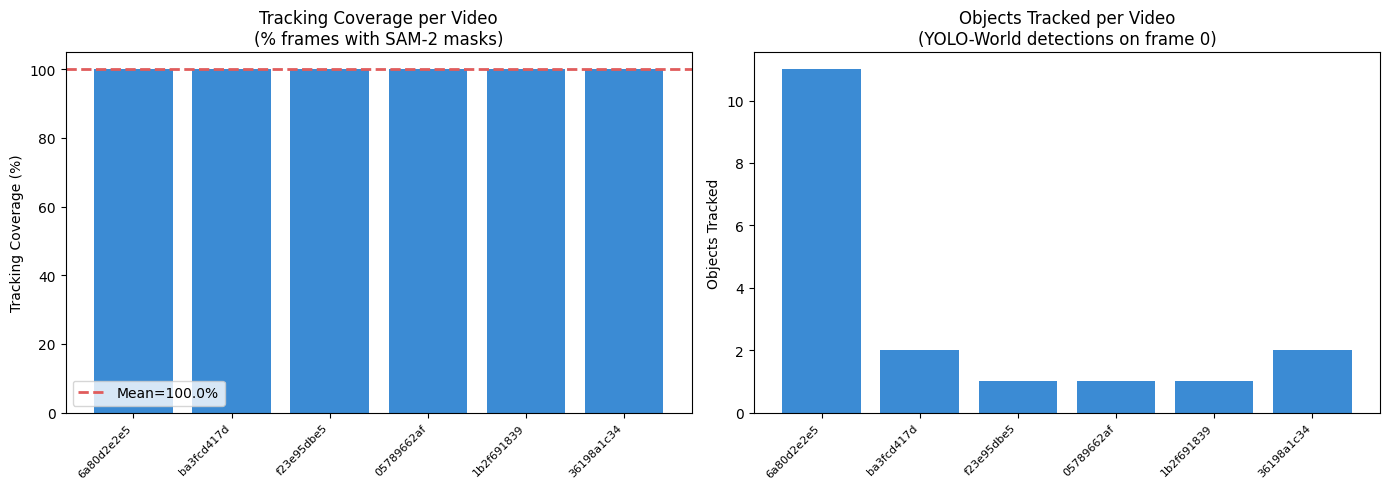

✅ Summary chart saved.


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 7: Save frame grids for each tracked video
# Shows: frame 1, frame N/4, frame N/2, frame 3N/4, frame N
# (temporal spread to visualise tracking progression)
# ─────────────────────────────────────────────────────────────

print("Generating visualization grids...")

for vid_id, annotated_frames in frame_annotations.items():
    info       = video_index[vid_id]
    vid_folder = info["vid_folder"]
    n_frames   = len(annotated_frames)

    if n_frames < 2:
        continue

    # Pick 5 evenly spaced frames for the grid
    indices = sorted(set([
        0,
        n_frames // 4,
        n_frames // 2,
        3 * n_frames // 4,
        n_frames - 1,
    ]))
    indices = [i for i in indices if i in annotated_frames][:5]

    fig, axes = plt.subplots(1, len(indices), figsize=(5*len(indices), 4))
    if len(indices) == 1:
        axes = [axes]

    for ax, fi in zip(axes, indices):
        ax.imshow(annotated_frames[fi])
        ax.set_title(f"Frame {fi+1}/{n_frames}", fontsize=9)
        ax.axis("off")

    # Find result for this video
    vid_result = next((r for r in all_tracking_results
                       if r["vid_id"] == vid_id), {})
    n_obj  = vid_result.get("n_objects_tracked", 0)
    cov    = vid_result.get("tracking_coverage", 0)

    plt.suptitle(
        f"Video {vid_folder} — {n_obj} objects tracked, "
        f"coverage={cov:.1%}",
        fontsize=11
    )
    plt.tight_layout()

    save_path = f"{STAGE_VIZ_GRIDS}/tracking_{vid_folder}.png"
    plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.close()
    print(f"  ✅ {vid_folder}: grid saved")

# ── Metrics bar chart ─────────────────────────────────────────
if len(df_metrics) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    folders = df_metrics["vid_folder"].tolist()
    x       = np.arange(len(folders))

    ax1.bar(x, df_metrics["tracking_coverage"] * 100, color="#3B8BD4")
    ax1.axhline(df_metrics["tracking_coverage"].mean() * 100,
                color="#E05C5C", lw=2, linestyle="--",
                label=f"Mean={df_metrics['tracking_coverage'].mean():.1%}")
    ax1.set_xticks(x); ax1.set_xticklabels(folders, rotation=45, ha="right", fontsize=8)
    ax1.set_ylabel("Tracking Coverage (%)")
    ax1.set_ylim(0, 105)
    ax1.set_title("Tracking Coverage per Video\n(% frames with SAM-2 masks)")
    ax1.legend()

    ax2.bar(x, df_metrics["n_objects"], color="#3B8BD4")
    ax2.set_xticks(x); ax2.set_xticklabels(folders, rotation=45, ha="right", fontsize=8)
    ax2.set_ylabel("Objects Tracked")
    ax2.set_title("Objects Tracked per Video\n(YOLO-World detections on frame 0)")

    plt.tight_layout()
    plt.savefig(f"{STAGE_VIZ_GRIDS}/tracking_summary_chart.png",
                dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Summary chart saved.")

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 8: Copy all outputs to Drive — single tar operation
#
# STAGE mirrors outputs/ structure:
#   STAGE/metrics/...               → OUTPUT_DIR/metrics/...
#   STAGE/visualizations/tracking*/ → OUTPUT_DIR/visualizations/tracking*/
# ─────────────────────────────────────────────────────────────

print("Copying all outputs to Drive...")
TAR_PATH = "/content/staging/tracking_outputs.tar.gz"

subprocess.run(f"tar -czf '{TAR_PATH}' -C '{STAGE}' .",
               shell=True, check=True)
subprocess.run(f"cp '{TAR_PATH}' '{OUTPUT_DIR}/' && sync",
               shell=True, check=True)
subprocess.run(f"tar -xzf '{OUTPUT_DIR}/tracking_outputs.tar.gz' -C '{OUTPUT_DIR}'",
               shell=True, check=True)
subprocess.run(f"rm '{OUTPUT_DIR}/tracking_outputs.tar.gz' && sync",
               shell=True, check=True)
print("✅ Outputs extracted to Drive.")

# ── Verify ────────────────────────────────────────────────────
print("\nVerifying files on Drive:")
expected = [
    (os.path.join(METRICS_DIR, "tracking_results.json"),    "tracking_results.json"),
    (os.path.join(METRICS_DIR, "tracking_per_video.csv"),   "tracking_per_video.csv"),
    (os.path.join(VIZ_DIR, "tracking_grids",
                  "tracking_summary_chart.png"),             "summary chart"),
]
all_ok = True
for path, label in expected:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    print(f"  {'✅' if exists else '❌'} {label} ({size:.1f} KB)")
    if not exists:
        all_ok = False

# Check tracking grids
grid_dir = os.path.join(VIZ_DIR, "tracking_grids")
n_grids  = len(os.listdir(grid_dir)) if os.path.isdir(grid_dir) else 0
print(f"  {'✅' if n_grids > 0 else '❌'} tracking grids: {n_grids} files")

if all_ok and n_grids > 0:
    print("\n✅ All outputs confirmed on Drive. Notebook 04 complete.")
    print("   Next → 05_final_pipeline.ipynb")
else:
    print("\n❌ Some files missing — check staging dir and re-run Cell 8.")

Copying all outputs to Drive...
✅ Outputs extracted to Drive.

Verifying files on Drive:
  ✅ tracking_results.json (1.6 KB)
  ✅ tracking_per_video.csv (0.3 KB)
  ✅ summary chart (62.3 KB)
  ✅ tracking grids: 7 files

✅ All outputs confirmed on Drive. Notebook 04 complete.
   Next → 05_final_pipeline.ipynb


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 9: Release VRAM
# ─────────────────────────────────────────────────────────────
import gc, torch

for obj in ["yw_model", "video_predictor", "inference_state"]:
    if obj in dir():
        del globals()[obj]
gc.collect()
torch.cuda.empty_cache()

free_gb = torch.cuda.mem_get_info()[0]/1e9 if torch.cuda.is_available() else 0
print(f"✅ VRAM cleared. Free: {free_gb:.1f} GB")
print("   Notebook 04 complete.")

✅ VRAM cleared. Free: 41.6 GB
   Notebook 04 complete.
